# P1 · 00 — First look: what does India's GDP *look like*, and how do we tame it?

**Project 1 goal:** master the classical forecasting toolkit on a real, *small*
macro series — India GDP. This first notebook is about **seeing the data clearly
and applying the two transforms that make GDP forecastable**: the *log* and the
*growth rate*.

By the end you can answer:
1. Why is a raw GDP plot misleading, and what does `log(GDP)` fix?
2. What is the difference between a *level*, a *log-level*, and a *growth rate*?
3. Why must time-series train/test splits respect time order?

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:  # silence statsmodels' chatty (harmless) convergence / lookup warnings
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

annual = data.load_annual()      # real GDP, constant LCU, 1960-2024
q = data.load_quarterly()        # real GDP, NSA + SA, 2004Q2-2026Q1
print("annual :", annual.index.min(), "->", annual.index.max(), "| n =", len(annual))
print("quarter:", q.index.min(), "->", q.index.max(), "| n =", len(q))
q.tail()

annual : 1960 -> 2024 | n = 65
quarter: 2004Q2 -> 2026Q1 | n = 88


,gdp_nsa,gdp_sa
quarter,,
2025Q1,81395975.0,76968444.5
2025Q2,75355723.5,78372204.8
2025Q3,75344227.1,80095365.2
2025Q4,84649351.7,81553807.7
2026Q1,87771040.1,83098964.7


### The three series we'll use all curriculum long

| name | freq | what | use |
|------|------|------|-----|
| `annual` | yearly | real GDP, constant LCU | long history → trend, ARIMA, tiny-sample backtests |
| `gdp_nsa` | quarterly | **N**ot **S**easonally **A**djusted | seasonality, decomposition, **SARIMA** |
| `gdp_sa` | quarterly | seasonally adjusted | contrast — *what adjustment removes* |

> ⚠️ **Do not compare the levels across these series.** Each uses a different
> base year / price base, so `annual` (≈10¹⁴) and the quarterly series (≈10⁷)
> are on different scales. Forecasting works *within* a series, so this is fine.

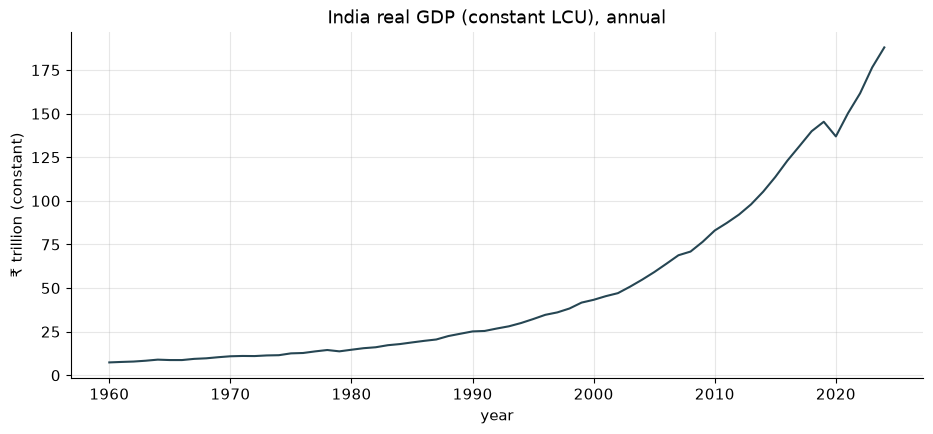

In [2]:
fig, ax = plt.subplots()
ax.plot(annual.index, annual.values / 1e12, color="#264653")
ax.set(title="India real GDP (constant LCU), annual",
       xlabel="year", ylabel="₹ trillion (constant)")
plt.show()

That curve **bends upward** — it grows *faster* as it gets bigger. That's the
signature of (roughly) **exponential growth**: GDP each year is about
`(1+g)` times the previous year. Two problems this creates for modelling:

* the *variance* grows with the level (recent wiggles dwarf 1960s wiggles),
* a straight-line model would badly underfit the recent years.

**The fix: take logs.** If $GDP_t \approx GDP_0 (1+g)^t$, then
$\log GDP_t \approx \log GDP_0 + t\log(1+g)$ — a **straight line** whose slope is
the growth rate. Logs turn multiplicative growth into additive growth.

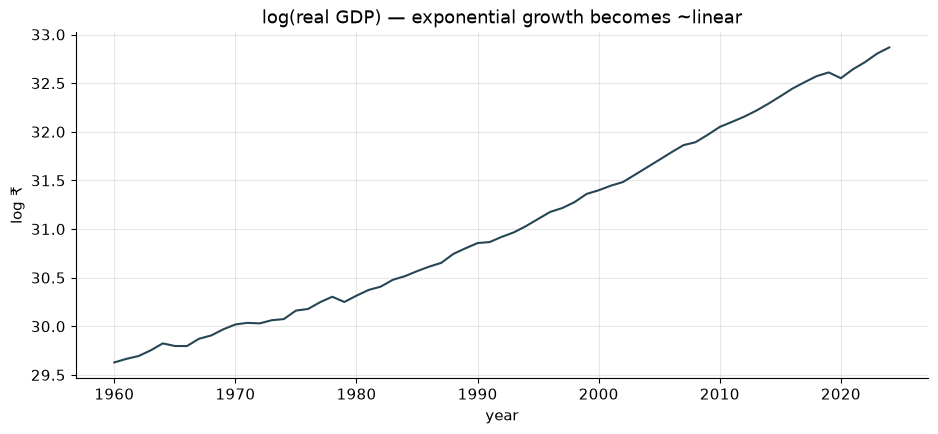

In [3]:
fig, ax = plt.subplots()
ax.plot(annual.index, np.log(annual.values), color="#264653")
ax.set(title="log(real GDP) — exponential growth becomes ~linear",
       xlabel="year", ylabel="log ₹")
plt.show()

Much straighter. The slope of this line *is* the average growth rate. We can
make growth explicit by **differencing the log**: the year-on-year growth rate is

$$g_t \;=\; \log GDP_t - \log GDP_{t-1} \;\approx\; \frac{GDP_t-GDP_{t-1}}{GDP_{t-1}}$$

(the `×100` makes it a percent). Differencing the log is the single most common
transform in macro forecasting — it converts a trending, non-stationary level
into a roughly **stationary** growth series we can actually model.

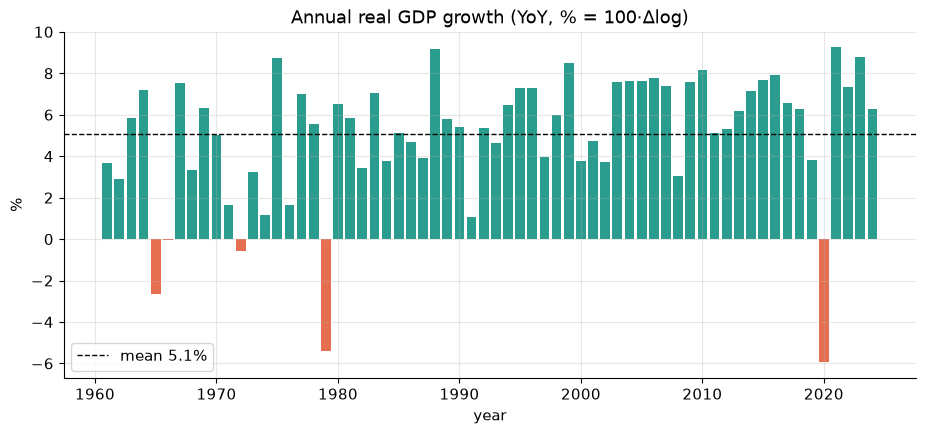

count    64.00
mean      5.06
std       3.14
min      -5.95
25%       3.75
50%       5.80
75%       7.31
max       9.25
Name: gdp, dtype: float64

In [4]:
g = np.log(annual).diff() * 100
fig, ax = plt.subplots()
ax.bar(g.index, g.values, color=np.where(g.values < 0, "#e76f51", "#2a9d8f"))
ax.axhline(g.mean(), color="k", ls="--", lw=1, label=f"mean {g.mean():.1f}%")
ax.set(title="Annual real GDP growth (YoY, % = 100·Δlog)", xlabel="year", ylabel="%")
ax.legend(); plt.show()
g.describe().round(2)

Now the *story* is visible: India's real GDP grew **~5–6% on average**, with
recognisable shocks — the **1991** balance-of-payments crisis, the **2008** GFC
dip, and the dramatic **2020 COVID** contraction followed by a sharp rebound.

A growth series like this is what classical models love: roughly constant mean,
roughly constant variance. Hold that thought — we'll *test* it formally in 01.

### Now the quarterly data: seasonality appears

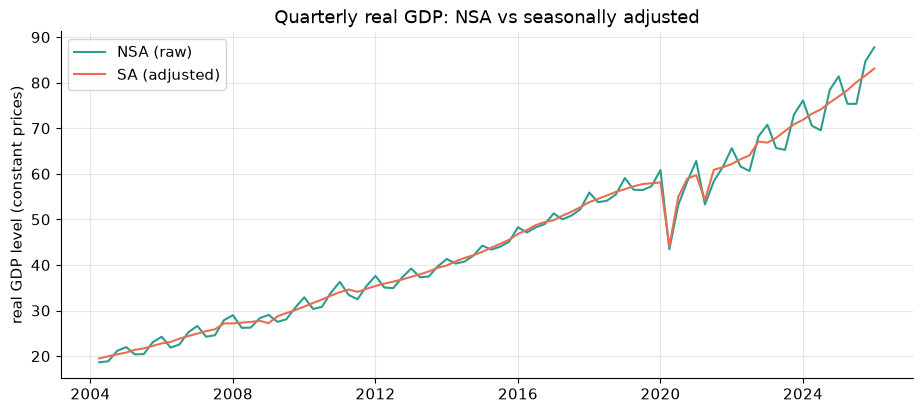

In [5]:
fig, ax = plt.subplots()
x = q.index.to_timestamp(how="start")
ax.plot(x, q["gdp_nsa"] / 1e6, label="NSA (raw)", color="#2a9d8f")
ax.plot(x, q["gdp_sa"] / 1e6, label="SA (adjusted)", color="#e76f51")
ax.set(title="Quarterly real GDP: NSA vs seasonally adjusted",
       ylabel="real GDP level (constant prices)")
ax.legend(); plt.show()

The green **NSA** line has a regular saw-tooth — that's **seasonality** (India's
Jan–Mar quarter is consistently the strongest). The orange **SA** line has that
repeating pattern statistically removed, leaving trend + irregular. Government
agencies publish SA series so analysts can read the *underlying* momentum without
the calendar getting in the way. In 01 we'll **decompose** the NSA series to
extract exactly that seasonal shape.

Two useful growth views of the quarterly data:
* **QoQ on the SA series** — quarter-to-quarter momentum (use SA so seasonality
  doesn't masquerade as growth).
* **YoY on the NSA series** — compare each quarter to the *same* quarter a year
  ago; the 4-quarter difference cancels seasonality automatically.

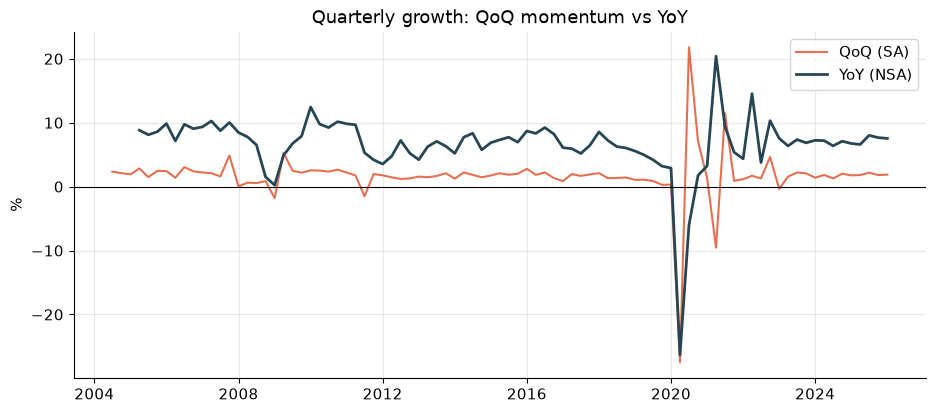

YoY mean %: 6.61 | COVID trough: -26.3 in 2020Q2


In [6]:
qoq = np.log(q["gdp_sa"]).diff() * 100        # quarter-on-quarter (SA)
yoy = np.log(q["gdp_nsa"]).diff(4) * 100      # year-on-year (NSA, 4-qtr diff)
fig, ax = plt.subplots()
ax.plot(x, qoq, label="QoQ (SA)", color="#e76f51")
ax.plot(x, yoy, label="YoY (NSA)", color="#264653", lw=2)
ax.axhline(0, color="k", lw=0.8)
ax.set(title="Quarterly growth: QoQ momentum vs YoY", ylabel="%")
ax.legend(); plt.show()
print("YoY mean %:", round(yoy.mean(), 2), "| COVID trough:", round(yoy.min(), 1),
      "in", yoy.idxmin())

### Golden rule: time-series splits respect time

You will be tempted to use a normal random train/test split. **Don't.** Shuffling
puts *future* points in the training set, so the model "remembers" what it's meant
to predict — accuracy looks great in the notebook and collapses in production.

The only valid split is **chronological**: train on the past, test on the most
recent tail. And a single tail split is fragile (it depends on one lucky/unlucky
window), so in notebook 02 we'll upgrade to **rolling-origin backtesting**.

---
**Next (01):** decompose the seasonal pattern and *formally test* whether our
transformed series are stationary — the prerequisite for ARIMA.